## Random Forest Regression Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder
from sklearn.tree import plot_tree

In [2]:
df = pd.read_csv('data/finalCards.csv')
df.head()

,uuid,cardName,availability,colorIdentity,defense,edhrecRank,edhrecSaltiness,finishes,isAlternative,isGameChanger,...,isRogue,isShaman,isDruid,isCreature,isPlaneswalker,isMTGO,isLegal,isBanned,isBattle,isFlying
0,00010d56-fe38-5e35-8aed-518019aa36a5,Sphinx of the Final Word,paper,U,NaN,10186.0,0.14,foil,False,False,...,False,False,False,True,False,False,True,False,False,True
1,0001e0d0-2dcd-5640-aadc-a84765cf5fc9,Goblin King,paper,R,NaN,3454.0,0.34,nonfoil,False,False,...,False,False,False,True,False,False,True,False,False,False
2,0003caab-9ff5-5d1a-bc06-976dd0457f19,Caravan Vigil,"mtgo, paper",G,NaN,12489.0,0.08,"nonfoil, foil",False,False,...,False,False,False,False,False,True,True,False,False,False
3,0003d249-25d9-5223-af1e-1130f09622a7,Deadshot Minotaur,"mtgo, paper","G, R",NaN,25150.0,0.20,"nonfoil, foil",False,False,...,False,False,False,True,False,True,True,False,False,False
4,0004822c-c181-5564-808d-a6cc48359a1a,Clone Legion,"arena, mtgo, paper",U,NaN,3488.0,0.48,"nonfoil, foil",False,False,...,False,False,False,False,False,True,True,False,False,False


In [3]:
df.columns

Index(['uuid', 'cardName', 'availability', 'colorIdentity', 'defense',
       'edhrecRank', 'edhrecSaltiness', 'finishes', 'isAlternative',
       'isGameChanger', 'isPromo', 'isReprint', 'isReserved', 'keywords',
       'layout', 'loyalty', 'manaCost', 'manaValue', 'cardNumber', 'power',
       'rarity', 'setCode', 'subtypes', 'supertypes', 'text', 'toughness',
       'types', 'variations', 'price', 'commander', 'setName', 'releaseDate',
       'scryfallId', 'tcgplayerProductId', 'multiverseId', 'isHuman',
       'isElemental', 'isDragon', 'isSpirit', 'isAngel', 'isElf', 'isVampire',
       'isZombie', 'isBeast', 'isEldrazi', 'isWizard', 'isSoldier', 'isKnight',
       'isCleric', 'isWarrior', 'isRogue', 'isShaman', 'isDruid', 'isCreature',
       'isPlaneswalker', 'isMTGO', 'isLegal', 'isBanned', 'isBattle',
       'isFlying'],
      dtype='object')

### Feature selection

In [4]:
# convert boolean columns (True/False) to int (1/0)
bool_cols = ['isAlternative','isGameChanger','isPromo','isReprint',
            'isReserved','isHuman','isElemental', 'isDragon', 
            'isSpirit', 'isAngel', 'isElf', 'isVampire',
            'isZombie', 'isBeast', 'isEldrazi', 'isWizard', 
            'isSoldier', 'isKnight','isCleric', 'isWarrior', 
            'isRogue', 'isShaman', 'isDruid', 'isCreature',
            'isPlaneswalker', 'isMTGO', 'isLegal', 'isBanned', 
            'isBattle', 'isFlying']
df[bool_cols] = df[bool_cols].astype(int)

In [5]:
df['colorIdentity'] = df['colorIdentity'].str.split(', ')

In [6]:
creature_df = df[(df['isCreature'] == 1)].copy().reset_index()
creature_df = creature_df[['colorIdentity', 'edhrecRank', 'edhrecSaltiness',
                           'isAlternative', 'isGameChanger', 'isPromo', 'isReserved',
                            'manaValue', 'power', 'rarity', 'isReprint', 'supertypes',
                            'toughness', 'price', 'isHuman', 'isElemental', 'isDragon',
                            'isSpirit', 'isAngel', 'isElf', 'isVampire', 'isZombie',
                            'isBeast', 'isWizard', 'isSoldier', 'isKnight', 'isCleric',
                            'isWarrior', 'isRogue', 'isShaman', 'isDruid', 'isFlying',
                            'isEldrazi']]

len(creature_df)

44836

In [7]:
creature_df['isLegendary'] = creature_df['supertypes'].str.contains('Legendary').astype(int)
creature_df.drop('supertypes', axis=1, inplace=True)

creature_df['isLegendary'].value_counts()

isLegendary
0    34571
1    10265
Name: count, dtype: int64

In [8]:
# one-hot encode color identity and rarity
mlb = MultiLabelBinarizer()
encoded_colors = mlb.fit_transform(creature_df['colorIdentity'])
colors_df = pd.DataFrame(encoded_colors, columns='c_'+mlb.classes_, index=creature_df.index)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_rarity = ohe.fit_transform(creature_df[['rarity']])
rarity_df = pd.DataFrame(encoded_rarity, columns=ohe.get_feature_names_out(['rarity']), index=creature_df.index)

features = pd.concat([colors_df, rarity_df], axis=1)
features.head()

,c_B,c_Colorless,c_G,c_R,c_U,c_W,rarity_common,rarity_mythic,rarity_rare,rarity_special,rarity_uncommon
0,0,0,0,0,1,0,0.0,1.0,0.0,0.0,0.0
1,0,0,0,1,0,0,0.0,0.0,1.0,0.0,0.0
2,0,0,1,1,0,0,1.0,0.0,0.0,0.0,0.0
3,1,0,0,0,0,0,0.0,1.0,0.0,0.0,0.0
4,0,0,0,0,1,0,0.0,0.0,0.0,0.0,1.0


In [9]:
creature_df = creature_df.join(features)
creature_df.drop(columns=['colorIdentity', 'rarity'], axis=1, inplace=True)
creature_df.columns

Index(['edhrecRank', 'edhrecSaltiness', 'isAlternative', 'isGameChanger',
       'isPromo', 'isReserved', 'manaValue', 'power', 'isReprint', 'toughness',
       'price', 'isHuman', 'isElemental', 'isDragon', 'isSpirit', 'isAngel',
       'isElf', 'isVampire', 'isZombie', 'isBeast', 'isWizard', 'isSoldier',
       'isKnight', 'isCleric', 'isWarrior', 'isRogue', 'isShaman', 'isDruid',
       'isFlying', 'isEldrazi', 'isLegendary', 'c_B', 'c_Colorless', 'c_G',
       'c_R', 'c_U', 'c_W', 'rarity_common', 'rarity_mythic', 'rarity_rare',
       'rarity_special', 'rarity_uncommon'],
      dtype='object')

In [10]:
def priceOutlier(df):
    df['Zscore'] = zscore(df['price'])

    no_outliers = df[df['Zscore'].abs() <= 3]
    no_outliers = no_outliers.drop(columns=['Zscore'])
    print(len(df), len(no_outliers))

    return no_outliers

In [11]:
creature_df['price'].sort_values(ascending=False)

7031     20840.000000
23614     4827.996667
42093     3599.990000
3672      3515.540000
6635      3362.183333
             ...     
395          0.090000
43710        0.082000
13820        0.030000
21763        0.030000
42520        0.020000
Name: price, Length: 44836, dtype: float64

In [12]:
creature_df = priceOutlier(creature_df)
creature_df['price'].sort_values(ascending=False)

44836 44698


19984    369.745000
24626    369.440000
44190    364.281667
40412    360.890000
32675    350.714000
            ...    
395        0.090000
43710      0.082000
13820      0.030000
21763      0.030000
42520      0.020000
Name: price, Length: 44698, dtype: float64

In [13]:
# calculate correlation matrix with 'price' target, and only select features with correlation > 0.5
# target_variable = 'price'
# threshold = 0.05

# corr_matrix = creature_df.corr()
# target_corr = corr_matrix[target_variable]

# strong_features = target_corr[abs(target_corr) > threshold].index.tolist()

# print(f"Features with correlation > {threshold} with '{target_variable}':")
# print(strong_features)

# creature_df = creature_df[strong_features]

### Setup and train the model

In [14]:
y = creature_df['price']
X = creature_df.drop(columns=['price'], axis=1)

X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44698 entries, 0 to 44835
Data columns (total 41 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   edhrecRank       44074 non-null  float64
 1   edhrecSaltiness  37884 non-null  float64
 2   isAlternative    44698 non-null  int64  
 3   isGameChanger    44698 non-null  int64  
 4   isPromo          44698 non-null  int64  
 5   isReserved       44698 non-null  int64  
 6   manaValue        44698 non-null  float64
 7   power            43992 non-null  float64
 8   isReprint        44698 non-null  int64  
 9   toughness        44126 non-null  float64
 10  isHuman          44698 non-null  int64  
 11  isElemental      44698 non-null  int64  
 12  isDragon         44698 non-null  int64  
 13  isSpirit         44698 non-null  int64  
 14  isAngel          44698 non-null  int64  
 15  isElf            44698 non-null  int64  
 16  isVampire        44698 non-null  int64  
 17  isZombie         

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [5, 10],
    'max_features': ['sqrt', None]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='r2')

In [17]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=100; total time=   1.0s
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=100; total time=   0.8s
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=100; total time=   0.9s
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=100; total time=   0.9s
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=100; total time=   0.9s
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=200; total time=   1.7s
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=200; total time=   1.9s
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=200; total time=   1.9s
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=200; total time=   1.8s
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=200; total time=   1.9s
[CV] END ...max_depth=5, max_features=sqrt, n_estimators=500; total time=   4.5s
[CV] END ...max_depth=5, max_features=sqrt, n_es

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10], 'max_features': ['sqrt', None],
                         'n_estimators': [100, 200, 500]},
             scoring='r2', verbose=2)

In [18]:
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best R-squared score: {grid_search.best_score_}")

Best parameters found: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 500}
Best R-squared score: 0.1277737132070331


### Evaluate the model

In [19]:
model = grid_search.best_estimator_
y_pred = model.predict(X_test)

In [20]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae:.2f}')
print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')

Mean Absolute Error: 5.05
Mean Squared Error: 375.18
R-squared: 0.14


### Visualize feature importance

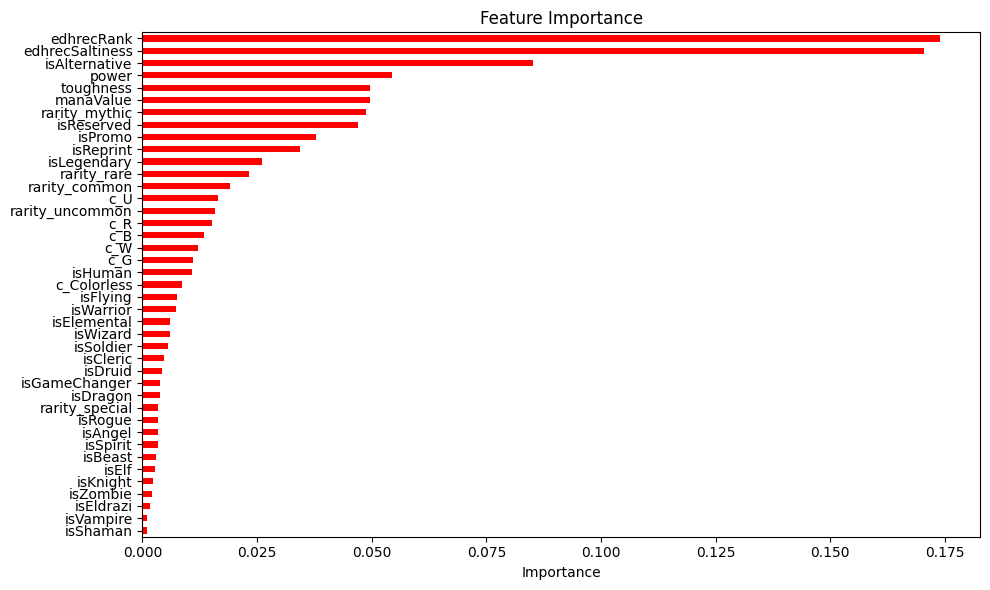

In [21]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 6), color='r')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Plot single decision tree

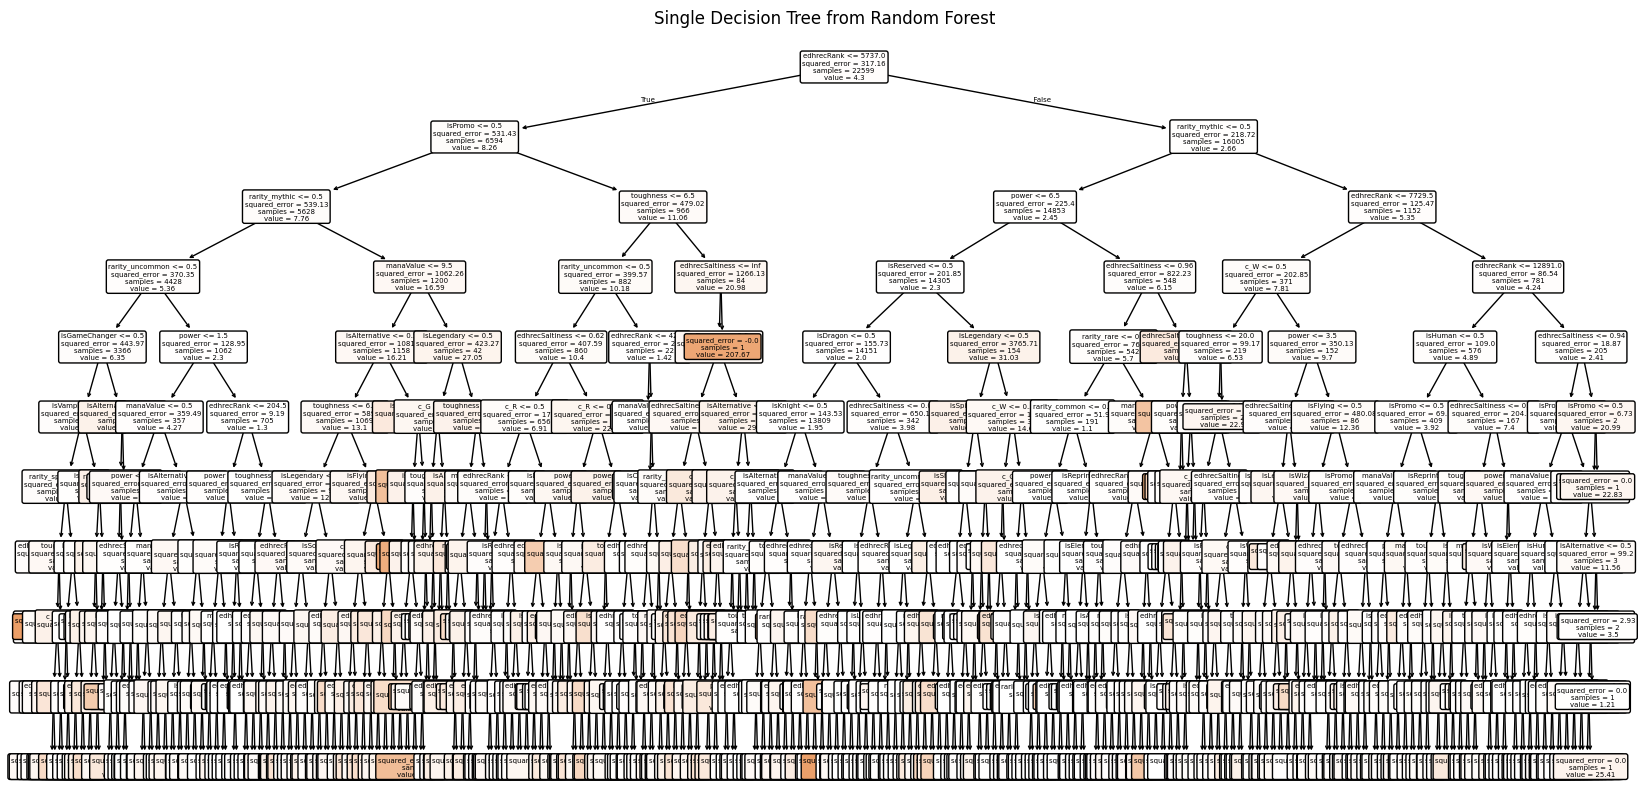

In [22]:
estimator = model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(estimator, 
          feature_names=X.columns,
          filled=True, 
          rounded=True,
          precision=2,
          proportion=False,
          fontsize=5,
          max_depth=10)
plt.title("Single Decision Tree from Random Forest")
plt.show()